In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3
print ("Les librairies sont chargées")


Les librairies sont chargées


# Chargement des données

In [40]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")


# Exploration des données(EDA)

In [41]:
orders.info()
orders.head()
orders.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [42]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [43]:
delivered = len(orders[orders["order_status"]=="delivered"])
total = len(orders)
pourcentage = (delivered / total) * 100
print (round(pourcentage, 2), "%")

97.02 %


97 % des commandes ont étés livrées, ce qui indique une bonne performance de la livraison de la plateforme. Les 3 % restants se répartissent entre commandes annulées , en cours de traitement ou indisponibles.

In [44]:
print(orders["order_purchase_timestamp"].min())
print(orders["order_purchase_timestamp"].max())

2016-09-04 21:15:19
2018-10-17 17:30:18


Nos données couvrent la période du 04 septembre 2016 au 17 octobre 2018. Cela veut dire que la liste des commandes que nous avons ont étés passées dans cette période.


# Nettoyage de données ( Data Cleaning )

In [45]:
orders["order_purchase_timestamp"]= pd.to_datetime(orders["order_purchase_timestamp"])
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  str           
 5   order_delivered_carrier_date   97658 non-null  str           
 6   order_delivered_customer_date  96476 non-null  str           
 7   order_estimated_delivery_date  99441 non-null  str           
dtypes: datetime64[us](1), str(7)
memory usage: 6.1 MB


In [46]:
orders_clean = orders[orders["order_status"]=='delivered']
len(orders_clean)

96478

Pour assurer le bon fonctionnement de notre travail, nous avons converti la colonne de dates en datetime et filtré les commandes pour ne garder que les commandes qui ont pour statuts "livrée".

# Analyse SQL

In [47]:
conn = sqlite3.connect(":memory:")

In [48]:
orders_clean.to_sql("orders", conn, index = False, if_exists ="replace")
products.to_sql("products",conn, index = False, if_exists ="replace" )
items.to_sql("items", conn, index = False, if_exists ="replace")
customers.to_sql("customers", conn, index = False, if_exists ="replace")
payments.to_sql("payments", conn, index = False, if_exists ="replace")

103886

Nous venons de transformer les dataframes en tables dans SQL.


In [49]:
query = """
SELECT ROUND(AVG(payment_value),2) AS panier_moyen
FROM payments
"""
pd.read_sql(query, conn)

,panier_moyen
0,154.1


Le panier moyen d'un client est de 154.1

In [50]:
print(orders.head())


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [51]:
print(payments.head())

                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   
3  ba78997921bbcdc1373bb41e913ab953                   1  credit_card   
4  42fdf880ba16b47b59251dd489d4441a                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  
3                     8         107.78  
4                     2         128.45  


In [52]:
query = """
SELECT strftime('%Y-%m', order_purchase_timestamp) AS mois,SUM(payment_value) AS chiffre_affaires
FROM orders
JOIN payments ON orders.order_id = payments.order_id
GROUP BY mois
ORDER BY mois ;
"""

ca_par_mois = pd.read_sql (query, conn)
print(ca_par_mois)

       mois  chiffre_affaires
0   2016-10          46566.71
1   2016-12             19.62
2   2017-01         127545.67
3   2017-02         271298.65
4   2017-03         414369.39
5   2017-04         390952.18
6   2017-05         567066.73
7   2017-06         490225.60
8   2017-07         566403.93
9   2017-08         646000.61
10  2017-09         701169.99
11  2017-10         751140.27
12  2017-11        1153528.05
13  2017-12         843199.17
14  2018-01        1078606.86
15  2018-02         966510.88
16  2018-03        1120678.00
17  2018-04        1132933.95
18  2018-05        1128836.69
19  2018-06        1012090.68
20  2018-07        1027903.86
21  2018-08         985414.28


Le mois le plus rentable a été le mois de novembre 2017 avec un CA de 115000 reais. Cela pourrait s'expliquer par la période car en Novembre se déroule le Black Friday.


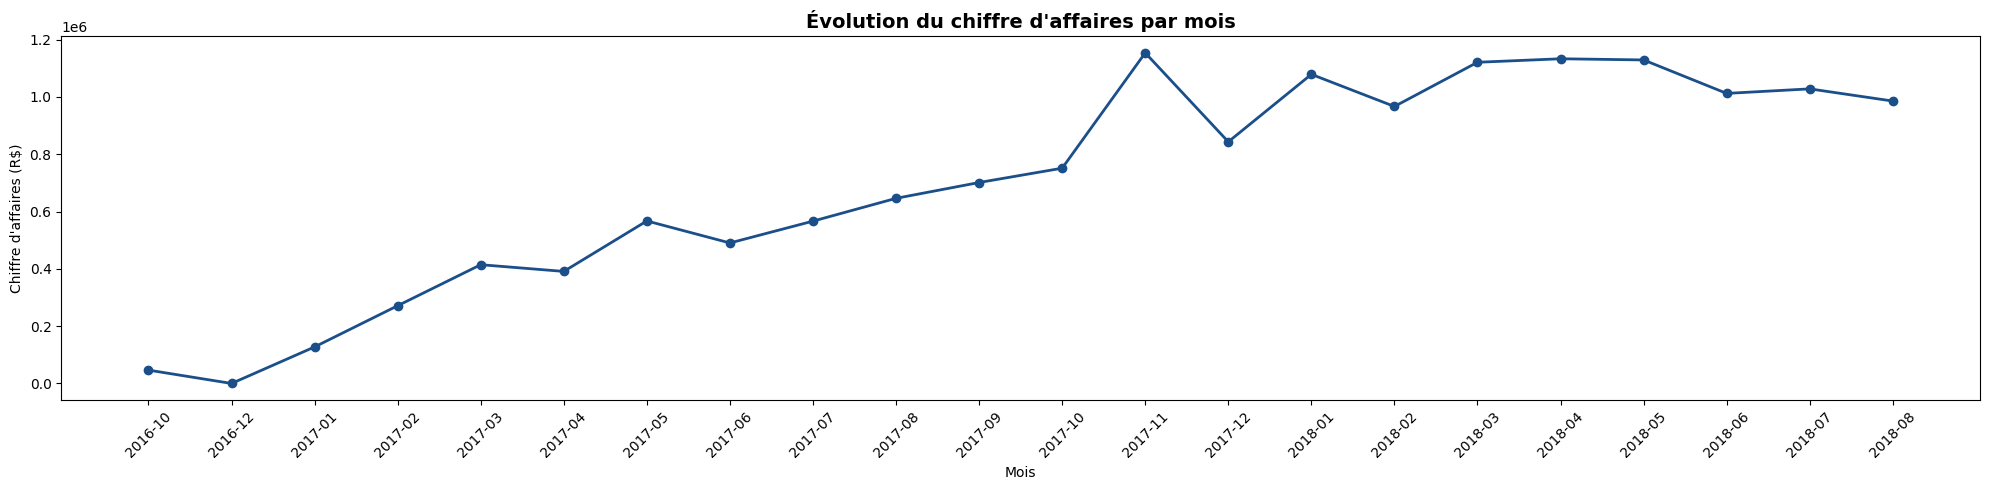

In [53]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(ca_par_mois["mois"], ca_par_mois["chiffre_affaires"], 
        color="#1B4F8A", marker="o", linewidth=2, markersize=6) 
ax.set_title("Évolution du chiffre d'affaires par mois", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Chiffre d'affaires (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/ca_par_mois.png", dpi=150, bbox_inches="tight")
plt.show()

# Analyse du CA par mois

Le chiffre d'affaires de la plateforme Olist montre une croissance 
progressive entre octobre 2016 et novembre 2017, avec quelques fluctuations. 
Un pic important est observé en novembre 2017, ce qui s'explique par le 
Black Friday. Après une légère baisse en décembre 2017, le CA se stabilise 
à un niveau élevé tout au long de 2018, signe de la maturité croissante 
de la plateforme. 
À noter : aucune donnée n'est disponible pour novembre 2016, 
probablement car la plateforme démarrait tout juste.

In [54]:
payments.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [55]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [56]:
query ="""
SELECT customer_state, AVG(payment_value) AS avg_payment
FROM payments 
JOIN orders ON payments.order_id = orders.order_id 
JOIN customers ON orders.customer_id = customers.customer_id 
GROUP BY customer_state 
ORDER BY avg_payment DESC;
"""

moyenne_ca_par_region = pd.read_sql(query, conn)
print(moyenne_ca_par_region.round(2))

   customer_state  avg_payment
0              PB       250.15
1              AC       235.98
2              AP       233.94
3              AL       229.19
4              RO       226.99
5              RR       220.48
6              PA       216.13
7              PI       208.87
8              SE       204.33
9              TO       203.41
10             MA       201.10
11             MT       199.61
12             CE       198.71
13             RN       197.12
14             MS       186.18
15             PE       185.41
16             AM       182.76
17             BA       169.76
18             GO       163.31
19             SC       162.58
20             DF       161.60
21             RJ       158.08
22             RS       155.45
23             MG       154.12
24             ES       153.62
25             PR       152.45
26             SP       136.39


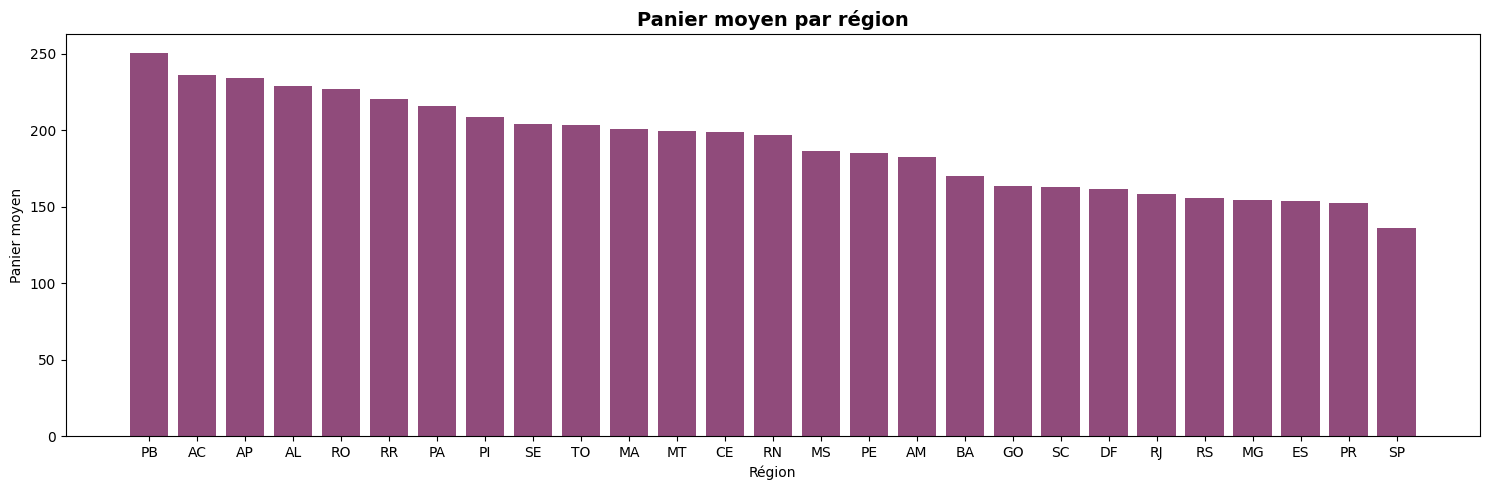

In [57]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(moyenne_ca_par_region["customer_state"],moyenne_ca_par_region["avg_payment"], color ="#904B7B")
plt.title("Panier moyen par région", fontsize=14, fontweight="bold")
plt.xlabel ("Région")
plt.ylabel("Panier moyen")
plt.tight_layout()
plt.savefig("../visuals/panier_moyen_par_region.png", dpi=150, bbox_inches="tight")
plt.show()

# Panier moyen par région
L'état de Paraíba (PB) affiche le panier moyen le plus élevé avec 250 R$, 
suivi de l'Acre (AC) avec 236 R$ et l'Amapá (AP) avec 234 R$. 
De manière surprenante, ce ne sont pas les grands états comme São Paulo 
ou Rio de Janeiro qui ont le panier moyen le plus élevé, mais des états 
du nord et nord-est du Brésil. Cela peut s'expliquer par un accès limité 
aux commerces physiques dans ces régions, poussant les habitants à dépenser 
davantage en ligne.

In [58]:
query =""" SELECT customer_state, SUM(payment_value) AS total_payment 
FROM payments 
JOIN orders ON payments.order_id = orders.order_id 
JOIN customers ON orders.customer_id = customers.customer_id 
GROUP BY customer_state 
ORDER BY total_payment DESC; 
""" 
revenu_total_par_region = pd.read_sql(query, conn) 
print(revenu_total_par_region)

   customer_state  total_payment
0              SP     5770266.19
1              RJ     2055690.45
2              MG     1819277.61
3              RS      861802.40
4              PR      781919.55
5              SC      595208.40
6              BA      591270.60
7              DF      346146.17
8              GO      334294.22
9              ES      317682.65
10             PE      309074.59
11             CE      266463.97
12             PA      212027.55
13             MT      181441.72
14             MA      147807.29
15             PB      137834.65
16             MS      134421.54
17             PI      105272.17
18             RN      100728.30
19             AL       94195.79
20             SE       70289.13
21             TO       60007.37
22             RO       56975.70
23             AM       27596.18
24             AC       19586.25
25             AP       16141.81
26             RR        9039.52


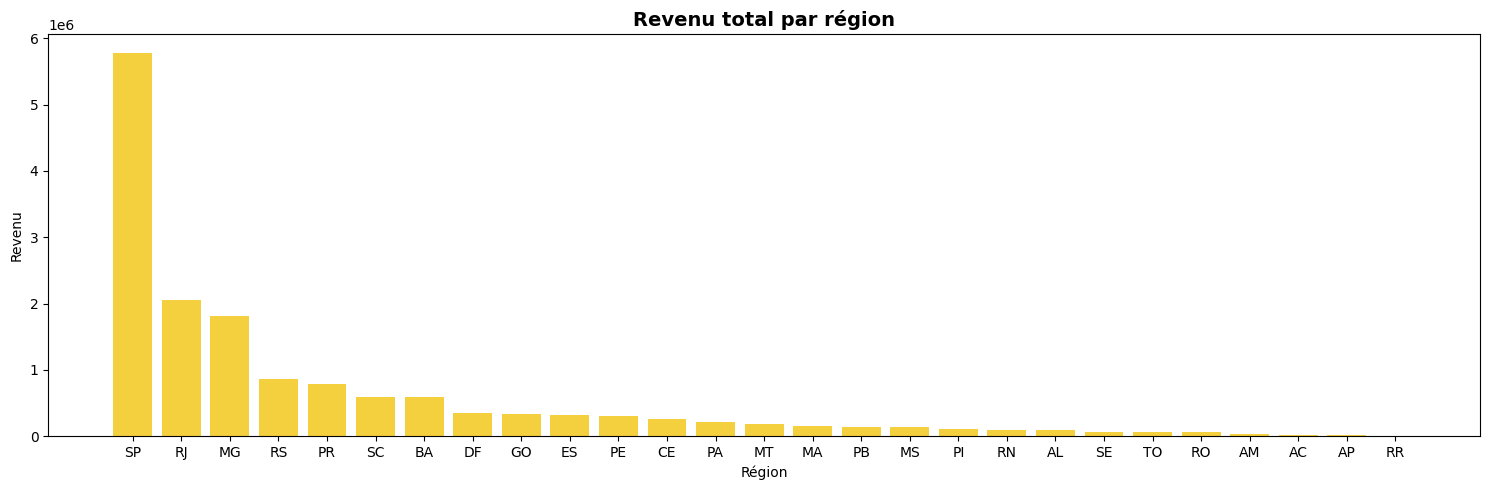

In [59]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(revenu_total_par_region["customer_state"],revenu_total_par_region["total_payment"], color ="#F4D03F")
plt.title("Revenu total par région", fontsize=14, fontweight="bold")
plt.xlabel ("Région")
plt.ylabel("Revenu")
plt.tight_layout()
plt.savefig("../visuals/revenu_total_par_region.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
query = """
SELECT p.product_category_name AS categorie,
       ROUND(SUM(i.price), 2) AS chiffre_affaires
FROM items i
JOIN products p ON i.product_id = p.product_id
GROUP BY categorie
ORDER BY chiffre_affaires DESC
LIMIT 10
"""
top_categories = pd.read_sql(query, conn)
print(top_categories)

                categorie  chiffre_affaires
0            beleza_saude        1258681.34
1      relogios_presentes        1205005.68
2         cama_mesa_banho        1036988.68
3           esporte_lazer         988048.97
4  informatica_acessorios         911954.32
5        moveis_decoracao         729762.49
6              cool_stuff         635290.85
7   utilidades_domesticas         632248.66
8              automotivo         592720.11
9      ferramentas_jardim         485256.46


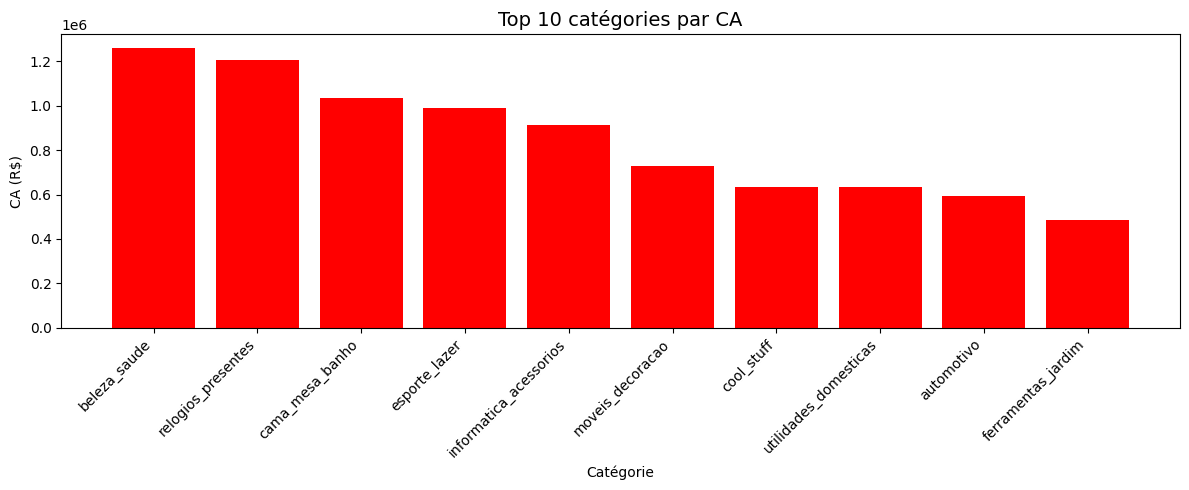

In [61]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_categories["categorie"], 
       top_categories["chiffre_affaires"], 
       color="r")
plt.title("Top 10 catégories par CA", fontsize=14)
plt.xlabel("Catégorie")
plt.ylabel("CA (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visuals/top_categories.png", dpi=150)
plt.show()

In [62]:
query = """
SELECT c.customer_state,
       ROUND(AVG(julianday(o.order_delivered_customer_date) - 
                 julianday(o.order_purchase_timestamp)), 1) AS delai_moyen_jours
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_status = 'delivered'
GROUP BY c.customer_state
ORDER BY delai_moyen_jours ASC
"""
delais = pd.read_sql(query, conn)
print(delais)

   customer_state  delai_moyen_jours
0              SP                8.8
1              MG               12.0
2              PR               12.0
3              DF               13.0
4              SC               15.0
5              RJ               15.3
6              RS               15.3
7              GO               15.6
8              MS               15.6
9              ES               15.8
10             TO               17.7
11             MT               18.1
12             PE               18.4
13             BA               19.3
14             RN               19.3
15             RO               19.4
16             PI               19.5
17             PB               20.4
18             AC               21.0
19             CE               21.3
20             SE               21.5
21             MA               21.6
22             PA               23.8
23             AL               24.5
24             AM               26.4
25             AP               27.2
2

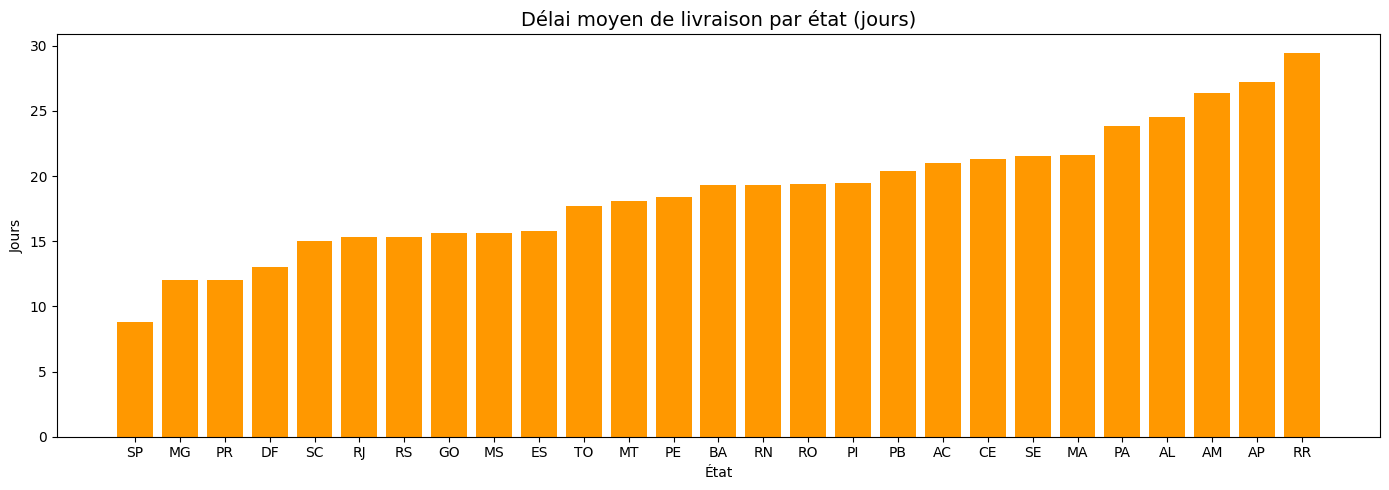

In [63]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(delais["customer_state"], 
       delais["delai_moyen_jours"], 
       color="#FF9800")
plt.title("Délai moyen de livraison par état (jours)", fontsize=14)
plt.xlabel("État")
plt.ylabel("Jours")
plt.tight_layout()
plt.savefig("../visuals/delais_livraison.png", dpi=150)
plt.show()

# Délai moyen de livraison par état

São Paulo (SP) affiche le délai le plus court avec 9 jours en moyenne, 
ce qui s'explique par la concentration des vendeurs et entrepôts dans 
cette région. À l'inverse, les états du nord comme Roraima (RR) et 
Amapá (AP) atteignent presque 30 jours, en raison de leur éloignement 
géographique et des infrastructures logistiques limitées.

In [64]:
query = """
SELECT payment_type,
       COUNT(*) AS nombre_transactions,
       ROUND(SUM(payment_value), 2) AS total_paye
FROM payments
GROUP BY payment_type
ORDER BY nombre_transactions DESC
"""
paiements = pd.read_sql(query, conn)
print(paiements)

  payment_type  nombre_transactions   total_paye
0  credit_card                76795  12542084.19
1       boleto                19784   2869361.27
2      voucher                 5775    379436.87
3   debit_card                 1529    217989.79
4  not_defined                    3         0.00


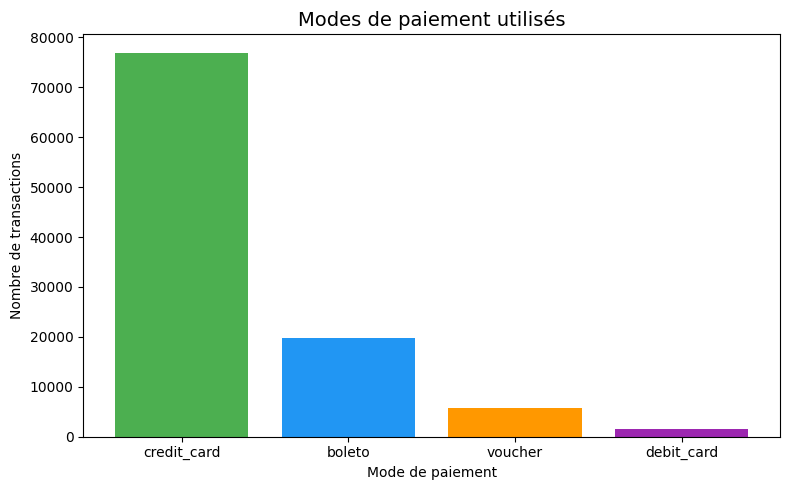

In [65]:
# On exclut "not_defined"
paiements_clean = paiements[paiements["payment_type"] != "not_defined"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(paiements_clean["payment_type"], 
       paiements_clean["nombre_transactions"], 
       color=["#4CAF50", "#2196F3", "#FF9800", "#9C27B0"])
plt.title("Modes de paiement utilisés", fontsize=14)
plt.xlabel("Mode de paiement")
plt.ylabel("Nombre de transactions")
plt.tight_layout()
plt.savefig("../visuals/modes_paiement.png", dpi=150)
plt.show()

In [66]:
import datetime

# Jointure orders_clean + payments pour avoir les montants
orders_payments = orders_clean.merge(
    payments[["order_id", "payment_value"]], 
    on="order_id", 
    how="left"
)

# Date de référence
date_ref = orders_clean["order_purchase_timestamp"].max() + datetime.timedelta(days=1)

# Calcul RFM
rfm = orders_payments.groupby("customer_id").agg(
    recency   = ("order_purchase_timestamp", lambda x: (date_ref - x.max()).days),
    frequency = ("order_id", "count"),
    monetary  = ("payment_value", "sum")
).reset_index()

rfm["monetary"] = rfm["monetary"].round(2)

print(rfm.head())
print(rfm.describe())

                        customer_id  recency  frequency  monetary
0  00012a2ce6f8dcda20d059ce98491703      288          1    114.74
1  000161a058600d5901f007fab4c27140      410          1     67.41
2  0001fd6190edaaf884bcaf3d49edf079      548          1    195.42
3  0002414f95344307404f0ace7a26f1d5      379          1    179.35
4  000379cdec625522490c315e70c7a9fb      150          1    107.01
            recency     frequency      monetary
count  96478.000000  96478.000000  96478.000000
mean     240.121364      1.044352    159.854700
std      152.836972      0.369601    218.812616
min        1.000000      1.000000      0.000000
25%      116.000000      1.000000     61.880000
50%      221.000000      1.000000    105.280000
75%      350.000000      1.000000    176.330000
max      714.000000     26.000000  13664.080000


In [67]:
# Scoring RFM de 1 à 4
rfm["R_score"] = pd.qcut(rfm["recency"], q=4, labels=[4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M_score"] = pd.qcut(rfm["monetary"], q=4, labels=[1, 2, 3, 4])

# Score global
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

# Segmentation
def segmenter(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])
    if r >= 3 and f >= 3:
        return "Champion"
    elif r >= 3 and f >= 2:
        return "Client fidèle"
    elif r >= 2 and f >= 2:
        return "À développer"
    elif r <= 2 and f <= 2:
        return "À risque"
    else:
        return "Dormant"

rfm["segment"] = rfm.apply(segmenter, axis=1)
print(rfm["segment"].value_counts())

segment
Dormant          24252
Champion         24022
À développer     18100
À risque         17937
Client fidèle    12167
Name: count, dtype: int64


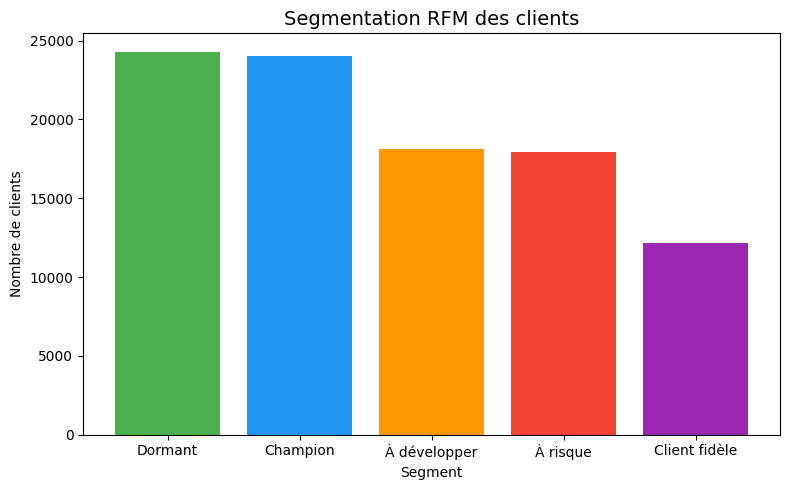

In [68]:
seg_counts = rfm["segment"].value_counts()

colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336", "#9C27B0"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seg_counts.index, seg_counts.values, color=colors)
plt.title("Segmentation RFM des clients", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
plt.tight_layout()
plt.savefig("../visuals/rfm_segmentation.png", dpi=150)
plt.show()

# Analyse RFM (Recency, Frequency, Monetary)

### Méthodologie
L'analyse RFM est une technique de segmentation client basée sur 3 dimensions :
- **Recency (R)** : nombre de jours depuis le dernier achat
- **Frequency (F)** : nombre de commandes passées
- **Monetary (M)** : montant total dépensé

Chaque client reçoit un score de 1 à 4 sur chaque dimension,
puis est classé dans un segment selon son comportement d'achat.

### Résultats clés
| Segment | Nombre | Description |
|---|---|---|
| Champion | 24 022 | Achat récent, fréquent, panier élevé |
| Client fidèle | 12 167 | Achats réguliers, bon panier |
| À développer | 18 100 | Potentiel existant, à stimuler |
| À risque | 17 937 | Inactivité croissante, à retenir |
| Dormant | 24 252 | Inactifs depuis longtemps |

### Insights business
- **25% de Champions** : un quart des clients est très engagé,
  ce sont les clients à fidéliser en priorité avec des offres exclusives.
- **25% de Dormants** : une campagne de réactivation ciblée
  (email, promotion) pourrait récupérer une partie de ce segment.
- **19% À risque** : signal d'alerte : ces clients montrent
  des signes de désengagement et nécessitent une action rapide.
- **Frequency médiane = 1** : la majorité des clients Olist
  n'achète qu'une seule fois, ce qui suggère un fort enjeu
  de fidélisation pour la plateforme.

## Conclusion générale

Cette analyse du dataset Olist (96 478 commandes livrées, 
période 2016–2018) a permis de dégager plusieurs insights clés :

**Performance globale**
- 97% des commandes sont livrées avec succès
- Le panier moyen est de 154 R$ avec une forte disparité régionale

**Chiffre d'affaires**
- Croissance continue entre 2016 et 2018
- Pic en novembre 2017 lié au Black Friday (+37% vs octobre)
- Stabilisation à un niveau élevé sur toute l'année 2018

**Géographie**
- São Paulo concentre 47% du revenu total
- Les états du nord (RR, AP) souffrent de délais 3x plus longs
  que São Paulo (29j vs 9j)

**Comportement client**
- 74% des paiements se font par carte de crédit
- La majorité des clients n'achète qu'une seule fois
- 25% de Champions à fidéliser, 25% de Dormants à réactiver

**Recommandations business**
1. Lancer une campagne de réactivation pour les 24 252 clients Dormants
2. Améliorer la logistique dans les états du nord
3. Développer des offres de fidélisation pour convertir les clients
   "À développer" en Champions

In [69]:
import os
os.makedirs("../data/exports", exist_ok=True)

In [70]:
# Export des tables pour Power BI
ca_par_mois.to_csv("../data/exports/ca_par_mois.csv", index=False)
delais.to_csv("../data/exports/delais_livraison.csv", index=False)
paiements_clean.to_csv("../data/exports/modes_paiement.csv", index=False)
top_categories.to_csv("../data/exports/top_categories.csv", index=False)
moyenne_ca_par_region.to_csv("../data/exports/panier_moyen_region.csv", index=False)
revenu_total_par_region.to_csv("../data/exports/revenu_total_region.csv", index=False)
rfm.to_csv("../data/exports/rfm_clients.csv", index=False)

print("✅ Tous les fichiers exportés avec succès !")

✅ Tous les fichiers exportés avec succès !


In [71]:
import os

# Chemin vers Downloads
downloads = os.path.expanduser("~/Downloads/exports_olist")
os.makedirs(downloads, exist_ok=True)

ca_par_mois.to_csv(f"{downloads}/ca_par_mois.csv", index=False, sep=";")
delais.to_csv(f"{downloads}/delais_livraison.csv", index=False, sep=";")
paiements_clean.to_csv(f"{downloads}/modes_paiement.csv", index=False, sep=";")
top_categories.to_csv(f"{downloads}/top_categories.csv", index=False, sep=";")
moyenne_ca_par_region.to_csv(f"{downloads}/panier_moyen_region.csv", index=False, sep=";")
revenu_total_par_region.to_csv(f"{downloads}/revenu_total_region.csv", index=False, sep=";")
rfm.to_csv(f"{downloads}/rfm_clients.csv", index=False, sep=";")

print(f"✅ Fichiers exportés dans : {downloads}")

✅ Fichiers exportés dans : C:\Users\Hp/Downloads/exports_olist


In [72]:
import os

downloads = os.path.expanduser("~/Downloads/exports_olist")
os.makedirs(downloads, exist_ok=True)

ca_par_mois.to_csv(f"{downloads}/ca_par_mois.csv", index=False, sep=";", decimal=",")
delais.to_csv(f"{downloads}/delais_livraison.csv", index=False, sep=";", decimal=",")
paiements_clean.to_csv(f"{downloads}/modes_paiement.csv", index=False, sep=";", decimal=",")
top_categories.to_csv(f"{downloads}/top_categories.csv", index=False, sep=";", decimal=",")
moyenne_ca_par_region.to_csv(f"{downloads}/panier_moyen_region.csv", index=False, sep=";", decimal=",")
revenu_total_par_region.to_csv(f"{downloads}/revenu_total_region.csv", index=False, sep=";", decimal=",")
rfm.to_csv(f"{downloads}/rfm_clients.csv", index=False, sep=";", decimal=",")

print("✅ Export avec point-virgule ET virgule décimale !")

✅ Export avec point-virgule ET virgule décimale !
